Found 1 API files and 1 profile files to visualize
Plotting callhub_api_times_latest.json


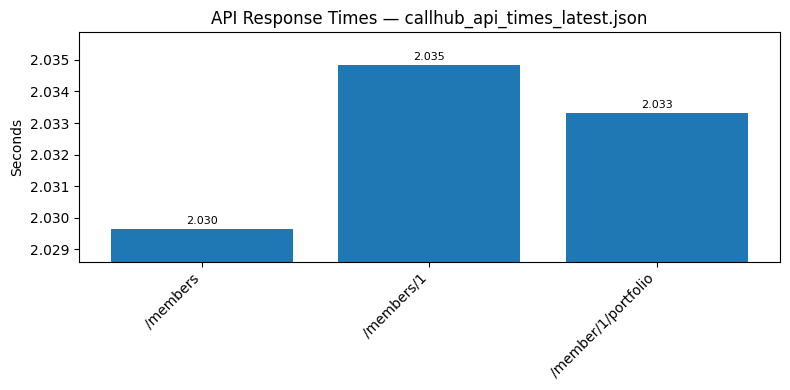

Plotting callhub_benchmark_profile_latest.json


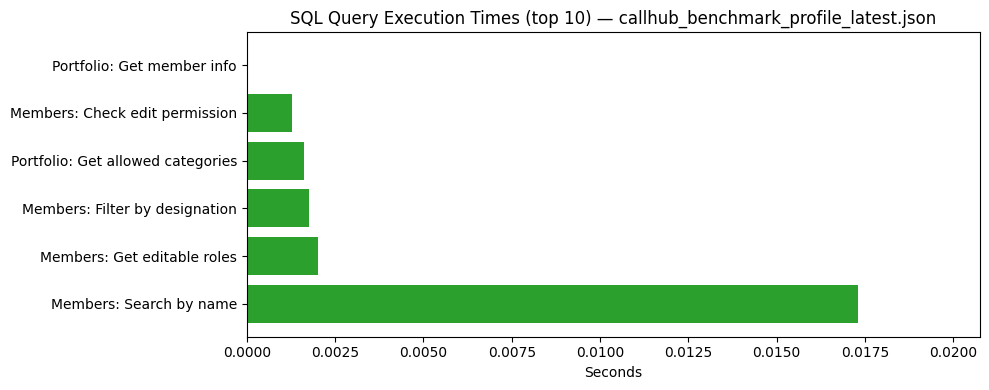

Graphs saved in d:\sia_db\CallHub-CS-432\Assignment2\Module B\callhub_backend\benchmarks\graphs


In [3]:
import json
import matplotlib.pyplot as plt
import os
import glob

# This notebook will locate all benchmark JSON snapshots in the `benchmarks/` folder
# and produce PNG graphs for each API timing and profile file. It also adjusts axis
# ranges and annotates values so small differences (e.g. 2.02 vs 2.03) are visible.

ROOT_API = 'callhub_api_times_latest.json'
ROOT_PROFILE = 'callhub_benchmark_profile_latest.json'
BENCH_DIR = os.path.join(os.getcwd(), 'benchmarks')
GRAPH_DIR = os.path.join(BENCH_DIR, 'graphs')
os.makedirs(GRAPH_DIR, exist_ok=True)

def load_json(p):
    if not os.path.exists(p):
        print(p, 'not found; skipping')
        return None
    with open(p, 'r', encoding='utf-8') as f:
        return json.load(f)

def plot_api_file(path, out_dir):
    data = load_json(path)
    if not data:
        return
    endpoints = [p.get('endpoint', str(i)) for i, p in enumerate(data)]
    times = [float(p.get('time', 0.0)) for p in data]
    plt.figure(figsize=(8,4))
    bars = plt.bar(endpoints, times, color='tab:blue')
    plt.ylabel('Seconds')
    plt.title(f'API Response Times — {os.path.basename(path)}')
    # adjust y-limits with a margin so very small differences are visible
    if times:
        ymin = min(times)
        ymax = max(times)
        span = max(ymax - ymin, 1e-6)
        margin = span * 0.2
        plt.ylim(ymin - margin, ymax + margin)
    plt.xticks(rotation=45, ha='right')
    # annotate values on bars
    for rect, val in zip(bars, times):
        y_off = (max(times) - min(times)) * 0.02 if len(times) > 1 else max(0.001, val * 0.02)
        plt.text(rect.get_x() + rect.get_width() / 2, val + y_off, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    out = os.path.join(out_dir, os.path.basename(path).replace('.json', '.png'))
    plt.savefig(out)
    plt.show()
    plt.close()

def plot_profile_file(path, out_dir, top_n=10):
    data = load_json(path)
    if not data:
        return
    sorted_p = sorted(data, key=lambda p: p.get('execution_time', 0), reverse=True)[:top_n]
    descs = [p.get('desc', '') for p in sorted_p]
    exe = [float(p.get('execution_time', 0)) for p in sorted_p]
    plt.figure(figsize=(10,4))
    bars = plt.barh(descs, exe, color='tab:green')
    plt.xlabel('Seconds')
    plt.title(f'SQL Query Execution Times (top {top_n}) — {os.path.basename(path)}')
    # set x-limits with margin
    if exe:
        xmin = min(exe)
        xmax = max(exe)
        span = max(xmax - xmin, 1e-6)
        margin = span * 0.2
        plt.xlim(max(0, xmin - margin), xmax + margin)
    plt.tight_layout()
    out = os.path.join(out_dir, os.path.basename(path).replace('.json', '_top.png'))
    plt.savefig(out)
    plt.show()
    plt.close()

# Gather files to visualize
api_files = sorted(glob.glob(os.path.join(BENCH_DIR, 'callhub_api_times_*.json')))
profile_files = sorted(glob.glob(os.path.join(BENCH_DIR, 'callhub_benchmark_profile_*.json')))
# include root-latest files if present
if os.path.exists(ROOT_API):
    api_files.append(ROOT_API)
if os.path.exists(ROOT_PROFILE):
    profile_files.append(ROOT_PROFILE)

print('Found', len(api_files), 'API files and', len(profile_files), 'profile files to visualize')

# Create graphs for all API timing snapshots
for p in api_files:
    print('Plotting', p)
    plot_api_file(p, GRAPH_DIR)

# Create graphs for all profile snapshots
for p in profile_files:
    print('Plotting', p)
    plot_profile_file(p, GRAPH_DIR)

print('Graphs saved in', GRAPH_DIR)

## EXPLAIN Plan Samples
Below are the EXPLAIN outputs captured in `callhub_benchmark_profile.json`. Each entry has an `explain` array containing explain rows. You can inspect these programmatically or copy them into the report PDF.

In [4]:
# Print a compact representation of the EXPLAIN for each profile snapshot
import glob, os
profile_files = sorted(glob.glob(os.path.join(os.getcwd(), 'benchmarks', 'callhub_benchmark_profile_*.json')))
if os.path.exists('callhub_benchmark_profile_latest.json'):
    profile_files.append('callhub_benchmark_profile_latest.json')

for pf in profile_files:
    data = load_json(pf)
    if not data:
        continue
    print('===', os.path.basename(pf))
    for item in data:
        print('---', item.get('desc'))
        explain = item.get('explain', [])
        if isinstance(explain, list):
            for row in explain[:5]:
                print(row)
        else:
            print(explain)
        print('\n')

=== callhub_benchmark_profile_latest.json
--- Portfolio: Get member info
[1, 'SIMPLE', 'Members', None, 'const', 'PRIMARY,idx_members_is_deleted,idx_members_isdeleted_fullname', 'PRIMARY', '4', 'const', 1, 100.0, None]


--- Portfolio: Get allowed categories
[1, 'SIMPLE', 'mra', None, 'ref', 'role_id,idx_mra_member_id', 'idx_mra_member_id', '4', 'const', 1, 100.0, 'Using temporary']
[1, 'SIMPLE', 'rp', None, 'ref', 'idx_rp_role_id,idx_rp_category_id', 'idx_rp_role_id', '5', 'callhub_db.mra.role_id', 5, 10.0, 'Using where']


--- Members: Check edit permission
[1, 'SIMPLE', 'Roles', None, 'const', 'role_title,idx_roles_role_title', 'role_title', '202', 'const', 1, 100.0, None]


--- Members: Get editable roles
[1, 'SIMPLE', 'Roles', None, 'index', None, 'role_title', '202', None, 12, 100.0, 'Using index']


--- Members: Search by name
[1, 'SIMPLE', 'Members', None, 'ALL', None, None, None, None, 4870, 11.11, 'Using where']


--- Members: Filter by designation
[1, 'SIMPLE', 'Members', No